In [2]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [25]:
def time_reader(f, time_correction=False):
    f=open(f)
    lines = f.readlines()
    time_map = {} 
    #start datetime: {end datetime: e_dt, network latency per img: nw, 
    # compute latency per imd : comp, throughput: th, batch_size: bs, num_batches: nb, 
    # total_time: e_dt - start_dt, (apply day correction if required) 
    # network latency total: nw_t, compute latency total: comp_t, 
    # flop: fp, s_per_op: s*10**9/op, nw_std: 0, comp_std: 0 } 
    dt_st=0
    dt_et=0
    last_iter = 0
    last_rank=False
    for line in lines:
        line=line.strip()
        if "startheat" in line:
            st = line.split("TIME:")[-1]
            dt_st = datetime.strptime(st, "%H:%M:%S.%f")
        if "Gloo" in line:
            # [Gloo] Rank 1 is connected to 2 peer ranks. Expected number of connected peer ranks is : 2
            rank = line.split(" ")[2]
            world = line.split(" ")[-1]
            last_rank = (rank==world)

        if "FLOP count" in line:
            #this means it was successful (probably)
            #create dict object here
            # rank 0 FLOP count: 472055808 and full time*10**9 s/op: 0.3508
            flop = line.split("count: ")[-1].split(" and ")[0]
            s_per_op = line.split("s/op: ")[-1]
            if dt_st==0:
                dt_st=1
                dt_et=1
                time_map[dt_st]={}
            time_map[dt_st] = {"e_dt":0, "nw":0, "comp":0, "th":0, "bs":0, "nb":0, "total_time":0, 
            "nw_t":0, "comp_t":0, "flop":int(flop), "s_per_op": float(s_per_op), "nw_std": 0, "comp_std": 0}
        elif "Time taken by rank:" in line:
            # Time taken by rank:1 in total(avg): 0.2246s 
            # Batch time sets raw:[[0.0576, 0.0]] 
            # Network sets raw:[[0.166, 0]] 
            # bytes sent:[] 
            # bytes recv:1605632 on 
            # avg per image: 0.0561s with std: 0.0000s 
            # network time: 0.0830s and network std: 0.0830s 
            # network time per img: 0.0207 compute time: 0.0354s 
            # compute/network ratio: 0.4264 and throughput 17.8129 img/s

            if dt_st==0:
                dt_st=1
                dt_et=1
                time_map[dt_st]={}
            nw_t = line.split("network time: ")[-1].split("s")[0]
            nw = line.split("network time per img: ")[-1].split(" ")[0]
            nw_std = line.split("network std: ")[-1].split("s")[0]
            comp_t = line.split("total(avg): ")[-1].split("s")[0]
            comp = line.split("avg per image: ")[-1].split("s")[0]
            comp_std = line.split("with std: ")[-1].split("s")[0]
            th = line.split("throughput ")[-1].split(" ")[0]
            recv = line.split("recv:")[-1].split(" ")[0]
            sent = ast.literal_eval("["+line.split("sent:[")[-1].split("] ")[0]+"]")
            if len(sent)>0:
                sent=sent[-1][-1]
            else:
                sent=0

            time_map[dt_st]["nw_t"] = float(nw_t)
            time_map[dt_st]["nw"] =  float(nw)
            time_map[dt_st]["nw_std"]=float(nw_std)
            time_map[dt_st]["comp_t"] =float(comp_t)
            time_map[dt_st]["comp"] = float(comp)
            time_map[dt_st]["comp_std"]=float(comp_std)
            time_map[dt_st]["th"]=float(th)
            time_map[dt_st]["sent"]=float(sent)
            time_map[dt_st]["recv"]=float(recv)

            block_times = ast.literal_eval(line.split("Batch time sets raw:")[-1].split("] ")[0]+"]")[-1]
            net_times = ast.literal_eval(line.split("Network sets raw:")[-1].split("] ")[0]+"]")[-1]            
            #combine lists and then np.cumulative_sum to get the block boundaries
            #plot them against throttle points and heatmap maybe? 
            #start on network, end on network, if any remaining compute -> leave as is
            timing = []
            while True:
                net_p = net_times.pop(0)
                timing.append(net_p)
                if len(net_times) == 0:
                    break
                comp_p = block_times.pop(0)
                timing.append(comp_p)
            if last_rank: #corner case when rank=world, checks gloo message to verify last rank
                timing.append(block_times.pop(0))

               
            time_map[dt_st]["timing"] = np.cumulative_sum([it for it in timing])
            #even index on cumulative sum is network, odd index is compute        

        if "Sync done" in line:
            # 2026-03-17 13:59:28.033112 Sync done -> model run start
            last_iter = datetime.strptime(line.split(" ")[1].split(".")[0], "%H:%M:%S") #this is compared against heatfiles
        if "endheat" in line:
            et  = line.split("TIME:")[-1]
            if dt_st not in time_map:
                break
            dt_et = datetime.strptime(et, "%H:%M:%S.%f")
            time_map[dt_st]["e_dt"] = dt_et
    
    if dt_et==0 or dt_st==0:
        return None, None
    if time_correction:
        pass

         
    return time_map, last_iter

[]

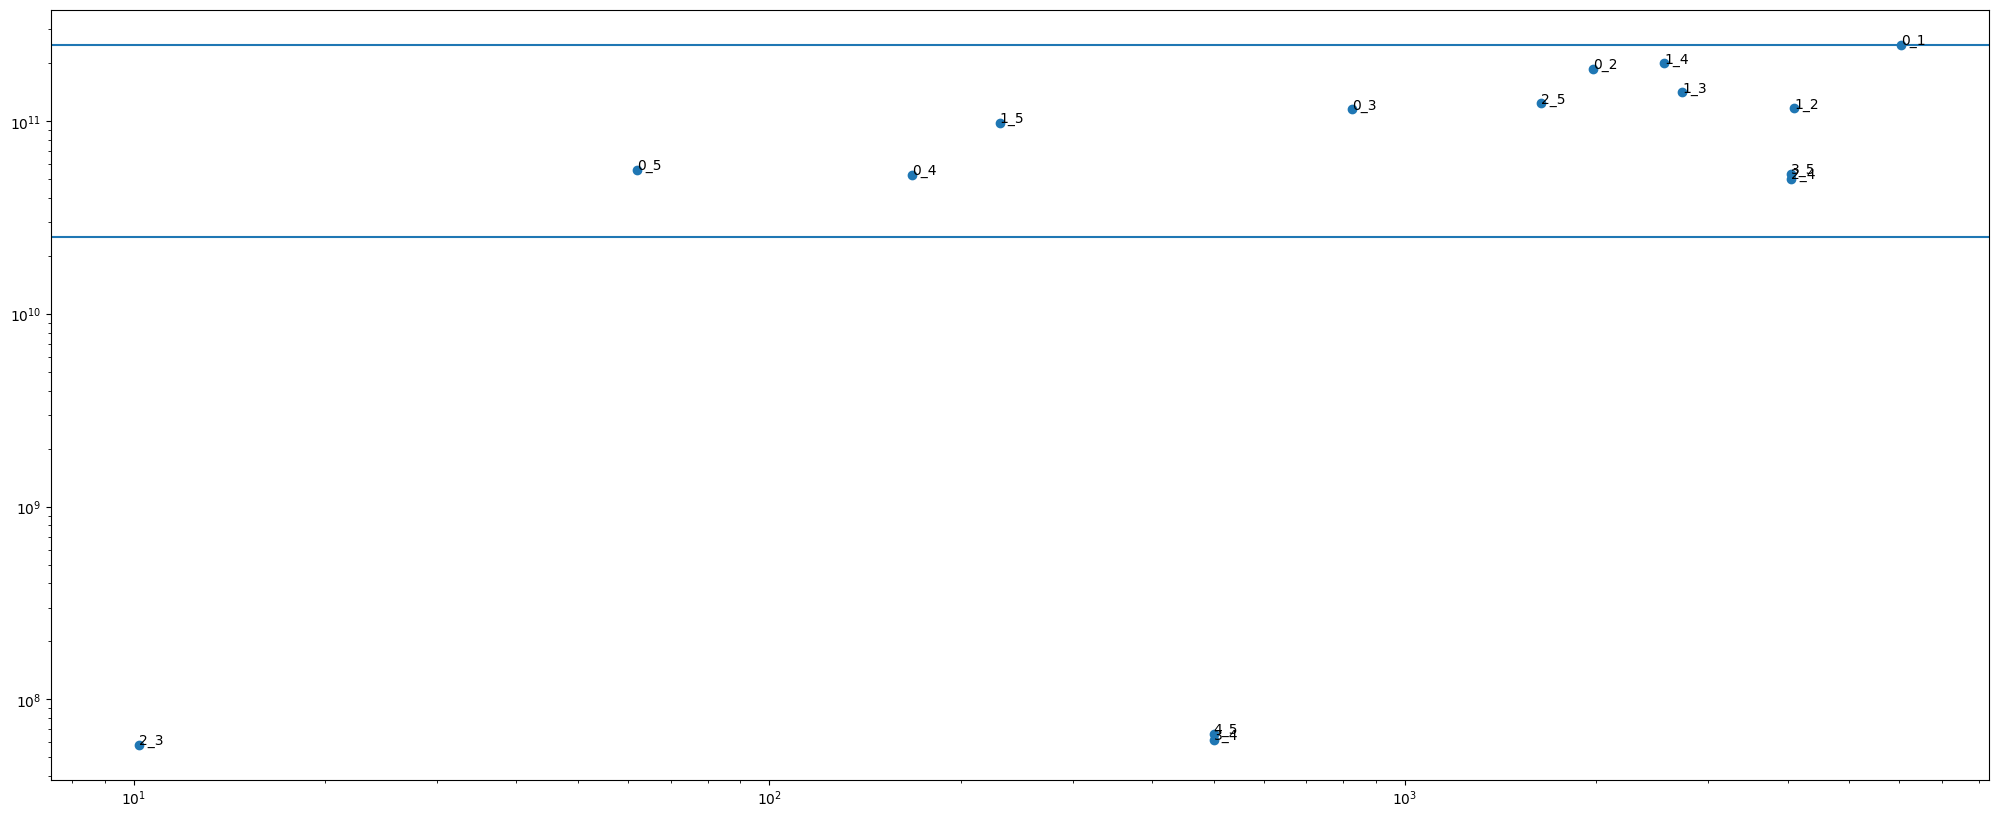

In [37]:
arith_intensity = [] #flops/bytes
flop_per_s = [] #flops/s
tags = []
for i in [1,2,3,4,5]:
    for rank in range(0,i):
        fname = f"/Users/animeshnd/model_splitting/logs/roofline/{i}_size/speed_chronos{rank}.log"
        time_map, last_iter = time_reader(fname)
        flop = time_map[1]["flop"]
        comp_t = time_map[1]["comp"]
        sent_b = time_map[1]["sent"]
        recv_b = time_map[1]["recv"]
        flop_per_s.append(flop/comp_t)
        arith_intensity.append(flop/(sent_b+recv_b))
        tags.append(f"{rank}_{i}")
        # print(fname)
        # print(time_map)
    #     break
    # break

fig, axs = plt.subplots(figsize=(25,10))
axs.scatter(arith_intensity, flop_per_s)
axs.axhline(y=flop_per_s[0])
axs.axhline(y=flop_per_s[0]*1/10) #pretending 10% range to theoretical max?
for r in range(len(arith_intensity)):
    axs.text(arith_intensity[r], flop_per_s[r], tags[r])
axs.loglog()
